# A simple model of seismic

Let's try to make the simplest possible 1D synthetic seismogram (normal incidence!).

We will do something like this:

    a stack of rocks -> acoustic properties -> impedance -> reflectivities -> convolution with a wavelet -> PROFIT

## Make an earth model

So we start with a stack of rocks that I will call 'the earth'. I'll define two Python `list` objects:

In [1]:
rocks = [
    'shale',
    'sandstone',
    'shale',
]

thicknesses = [
    30,  # We will treat this as "number of time samples"
    10,
    40,
]

And some rock properties, defined in a nested `dict` or dictionary:

In [2]:
lithologies = {
    'shale': {'Vp': 2400, 'Vs': 1150, 'rho': 2375},
    'sandstone': {'Vp': 2200, 'Vs': 1200, 'rho': 2250},
}

## Make geophysical logs

Now we can make logs. We can loop over the rocks and thicknesses together, to get pairs of data like `('shale', 30)`, `('sandstone', 10)`, etc. We will treat the thickness as "number of samples".

In [3]:
# Make 3 empty lists to store results.
vp, vs, rho = [], [], []

# Loop over the data:
for rock, thickness in zip(rocks, thicknesses):
    this_rock = lithologies[rock]
    vp.extend(thickness * [this_rock['Vp']])
    vs.extend(thickness * [this_rock['Vs']])
    rho.extend(thickness * [this_rock['rho']])

Now we can look at them.

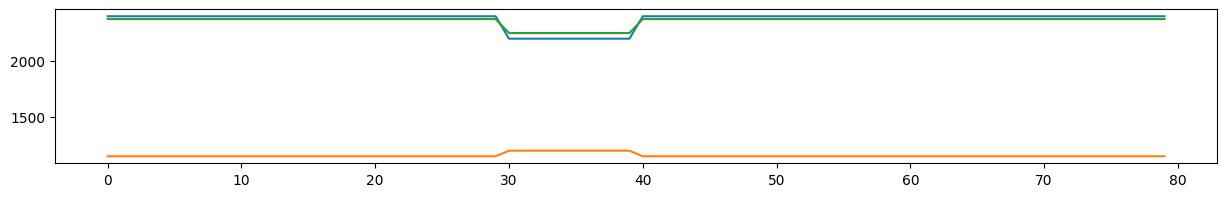

In [4]:
import matplotlib.pyplot as plt

# First, change the default figure size for convenience.
plt.rcParams['figure.figsize'] = [15, 2]

plt.plot(vp)
plt.plot(vs)
plt.plot(rho)

## Compute impedance and reflectivity

Let's stick to Vp and rho for now.

We can compute acoustic impedance easily, even without NumPy:

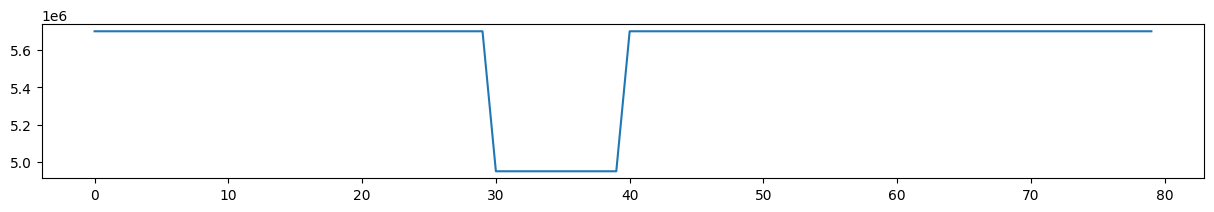

In [5]:
imp = [v * r for v, r in zip(vp, rho)]

plt.plot(imp)

Now reflectivity is just a running difference, which we can do with slicing:

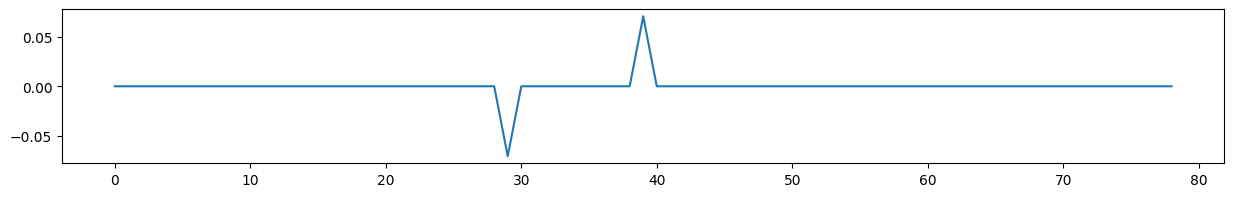

In [6]:
rc = [(lower - upper)/(lower + upper) for lower, upper in zip(imp[1:], imp[:-1])]

plt.plot(rc)

## Using NumPy

All this is even easier if we cast to NumPy arrays first:

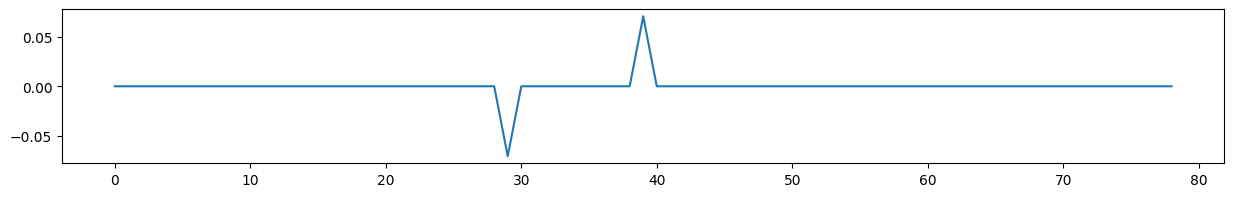

In [7]:
import numpy as np

vp = np.array(vp)
rho = np.array(rho)

imp = vp * rho

rc = (imp[1:] - imp[:-1]) / (imp[1:] + imp[:-1])

plt.plot(rc)

## Wavelet

/Users/MTHA/dev/notebooks/.venv/lib/python3.13/site-packages/bruges/__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


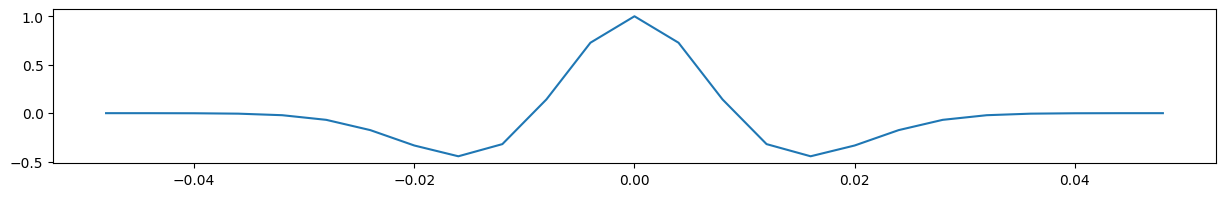

In [8]:
import bruges as bg

w, t = bg.filters.ricker(duration=0.1, dt=0.004, f=25)

plt.plot(t, w)

## Convolution

This is built into NumPy. Ususally we want `mode='same'` to preserve the shape of the input.

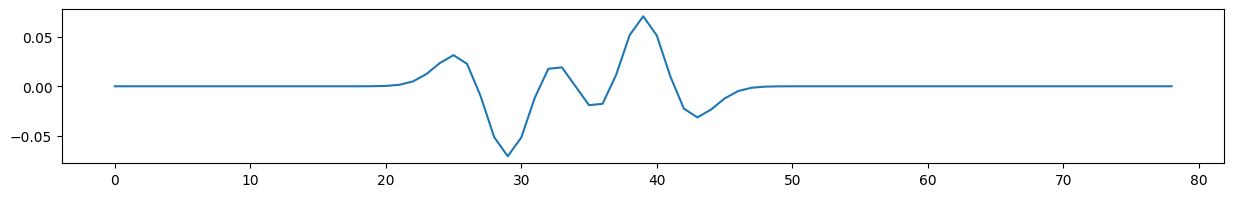

In [9]:
s = np.convolve(rc, w, mode='same')

plt.plot(s)

## Elastic modeling

We can incorporate the Vs and make a more accurate model, and even model over incidence angles.

We'll use the `bruges` library for this. It computes the reflectivity directly from the logs.

Note that it produces imaginary numbers.

We know that 0 deg offset will produce the acoustic result:

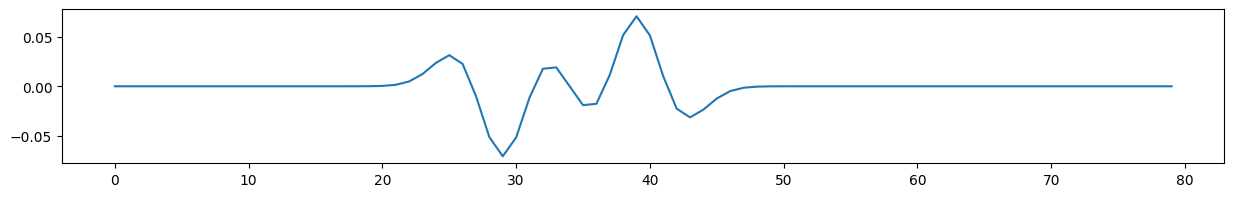

In [10]:
rc = bg.reflection.reflectivity(vp, vs, rho, theta=0)
s = np.convolve(rc, w, mode='same')
plt.plot(s.real)

But we can ask for 30 deg and plot it with the normal incidence result:

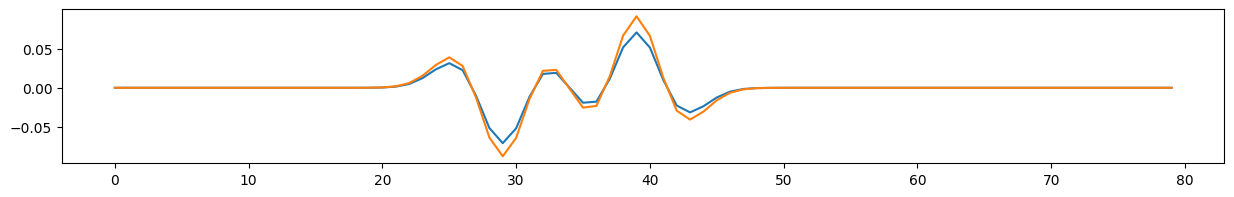

In [11]:
rc_30 = bg.reflection.reflectivity(vp, vs, rho, theta=30)
s_30 = np.convolve(rc_30, w, mode='same')

plt.plot(s.real)
plt.plot(s_30.real)

But we can also ask for all offsets and make a synthetic gather. This results in a 2D array so we have to do the convolution in a slightly different way, and use `imshow` to plot the result.

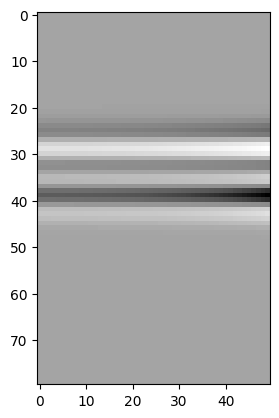

In [12]:
angles = np.arange(0, 50)

rc_g = bg.reflection.reflectivity(vp, vs, rho, theta=angles)
s_g = np.apply_along_axis(np.convolve, axis=1, arr=rc_g, v=w, mode='same').T

plt.figure(figsize=(3, 10))
plt.imshow(s_g.real, cmap='Grays')

---
&copy; Matt Hall 2025 — licensed CC BY, please share this work